# Bloch-Redfield Relaxation in MaRs: A Triplet‑14N Example

This notebook illustrates how to construct Bloch–Redfield relaxation channels
for a spin system consisting of a triplet electron (S=1) coupled to a $^{14}$N nucleus (I=1).
We consider five microscopic relaxation mechanisms:

1. Isotropic g‑factor modulation
2. ZFS parameter fluctuations (D and E)
3. Isotropic hyperfine coupling modulation
4. Librations around the molecular x‑, y‑, and z‑axes

For each mechanism we derive the coupling operator, normalise it to a common
dimensionless amplitude, and feed it into a `RedfieldRelaxationChannel` with a
simple spectral density.


\
\
\
\
\
\
For any questions, please contact Arkady Samsonenko via: \
Telegram: @Arkady_Samsonenko \
Email: a.samsonenko.tomo.nsc.ru
\
\
\
The last notebook update: 2026.07.30

In [1]:
# Import necessary libraries
import sys
import os
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

# Import Mars library components
import mars
from mars import spin_model, spectra_manager, mesher, constants
from mars import utils
from mars import population

# # Let's import some useful functions for plotting simulation results over time.
from mars import visualization
from mars import spin_model, population
from mars.population import RedfieldRelaxationChannel

In [2]:
muB = mars.constants.BOHR   # Bohr magneton in J/T
h = mars.constants.PLANCK   # Planck constant in J·s
muB_over_h = muB / h        # ≈ 1.3996e10 Hz/T  (or s⁻¹ T⁻¹)

device = torch.device('cpu')
dtype = torch.float64

#  1. Define Spin System and Sample

We use a simple axial g‑tensor, a ZFS with D=800 MHz, E=80 MHz, and a
hyperfine tensor with isotropic part ~50 MHz.

In [3]:
# --- g tensor ---
g_principal = torch.tensor([2.000, 2.002, 2.01], dtype=dtype, device=device)
g_inter = spin_model.Interaction(g_principal, device=device, dtype=dtype)

# --- ZFS ---
D_val = 800e6   # Hz
E_val = 80e6    # Hz
zfs = spin_model.DEInteraction([D_val, E_val], device=device, dtype=dtype)

# --- Hyperfine ---
A_principal = torch.tensor([40e6, 40e6, 80e6], dtype=dtype, device=device)  # Hz
A_inter = spin_model.Interaction(A_principal, device=device, dtype=dtype)

# --- SpinSystem ---
system = spin_model.SpinSystem(
    electrons=[1.0],   # one electron spin S=1
    nuclei=["14N"],         # one 14N nucleus I=1
    g_tensors=[g_inter],
    electron_electron=[(0, 0, zfs)],
    electron_nuclei=[(0, 0, A_inter)],
    device=device,
    dtype=dtype
)

# --- MultiOrientedSample (a small mesh for demonstration) ---
sample = spin_model.MultiOrientedSample(
    base_spin_system=system,
    gauss=3e-4,
    lorentz=3e-4,
    device=device,
    dtype=dtype
)

# 2. Helper Functions

We define functions that scale interactions of operator so that their total
Frobenius norm (over all dimensions) equals 1.  This allows us
to set a common coupling strength `coupling_strength` (dimensionless)
for all mechanisms.

In [4]:
def normalize_coupling(op: torch.Tensor, op_ndim: int = 2) -> torch.Tensor:
    """
    Normalize a coupling operator to have unit per‑orientation Frobenius norm
    averaged over all batch dimensions.

    :param op: Operator tensor. The last ``op_ndim`` dimensions are treated
        as the operator dimensions; all preceding dimensions are batch.
    :param op_ndim: Number of trailing dimensions forming the operator
    :return: Scaled operator of the same shape as ``op``.
    """
    op_flat = op.flatten(start_dim=-op_ndim)
    per_sample_norm = torch.linalg.vector_norm(op_flat, dim=-1)
    mean_norm = per_sample_norm.mean()
    if mean_norm == 0.0:
        return op
    return op / mean_norm


def normalize_tuple(
    static_op: torch.Tensor | None,
    field_op: torch.Tensor | None,
    op_ndim_static: int = 2,
    op_ndim_field: int = 2,
    eps: float = 1e-12,
) -> tuple[torch.Tensor | None, torch.Tensor | None]:
    """
    Normalize a pair of (static, field‑dependent) operators with a common
    factor so that the combined per‑orientation norm, averaged over all batch
    dimensions, equals 1.

    For each orientation the combined norm is
    :math:`\sqrt{||\text{static}||^2 + ||\text{field}||^2}`.
    The mean of these combined norms over the batch is used as the global
    scaling factor. Both operators are divided by this factor, preserving
    their relative weights.

    :param static_op: Static coupling operator (dimensionless).
        Shape ``(..., N, N)``. May be ``None``.
    :param field_op: Field‑dependent coupling operator (T\ :sup:`-1`).
        Shape ``(..., N, N)``. May be ``None``.
    :param op_ndim_static: Number of trailing dimensions of ``static_op``
        (default 2).
    :param op_ndim_field: Number of trailing dimensions of ``field_op``
        (default 3).
    :param eps: Small constant to avoid division by zero.
    :return: Tuple ``(scaled_static, scaled_field)``.
        Each element is ``None`` if the corresponding input was ``None``.
    """
    def per_sample_norm(op, ndim):
        flat = op.flatten(start_dim=-ndim)
        return torch.linalg.vector_norm(flat, dim=-1)

    combined_norm_sq = torch.tensor(0.0, dtype=dtype, device=device)
    batch_shape = None

    if static_op is not None:
        n_s = per_sample_norm(static_op, op_ndim_static)
        combined_norm_sq = combined_norm_sq + n_s ** 2
        batch_shape = n_s.shape
    if field_op is not None:
        n_f = per_sample_norm(field_op, op_ndim_field)
        combined_norm_sq = combined_norm_sq + n_f ** 2
        batch_shape = n_f.shape

    if batch_shape is None:
        return static_op, field_op

    combined_norm = torch.sqrt(combined_norm_sq + eps**2)
    mean_norm = combined_norm.mean()

    if mean_norm == 0.0:
        return static_op, field_op

    static_scaled = static_op / mean_norm if static_op is not None else None
    field_scaled  = field_op  / mean_norm if field_op  is not None else None

    return static_scaled, field_scaled


def normalize_tuple_list(
    operator_list: list[tuple[torch.Tensor | None, torch.Tensor | None]],
    op_ndim_static: int = 2,
    op_ndim_field: int = 2,
    eps: float = 1e-12,
) -> list[tuple[torch.Tensor | None, torch.Tensor | None]]:
    """
    Normalize a list of (static, field) operator tuples **simultaneously**
    with one global scaling factor.

    The total per‑orientation squared norm is summed over all operators
    (static and field) in all tuples.  The mean of this total norm over the
    batch dimensions is used as the global scaling factor.  Every operator
    is then divided by this same factor, preserving the relative strengths
    among all tuples.

    :param operator_list: List of tuples, each ``(static_op, field_op)``.
        Both elements can be ``None``.
    :param op_ndim_static: Trailing dimensions of static operators (default 2).
    :param op_ndim_field: Trailing dimensions of field operators (default 2).
    :param eps: Small constant to avoid division by zero.
    :return: List of normalised tuples, in the same order as the input.
    """
    def per_sample_norm(op, ndim):
        flat = op.flatten(start_dim=-ndim)
        return torch.linalg.vector_norm(flat, dim=-1)

    total_norm_sq = torch.tensor(0.0, dtype=dtype, device=device)
    batch_shape = None

    # Sum squared norms over all operators
    for static_op, field_op in operator_list:
        if static_op is not None:
            n_s = per_sample_norm(static_op, op_ndim_static)
            total_norm_sq = total_norm_sq + n_s ** 2
            batch_shape = n_s.shape
        if field_op is not None:
            n_f = per_sample_norm(field_op, op_ndim_field)
            total_norm_sq = total_norm_sq + n_f ** 2
            batch_shape = n_f.shape

    if batch_shape is None:
        return operator_list   # nothing to normalise

    total_norm = torch.sqrt(total_norm_sq + eps**2)   # per‑orientation total
    mean_norm = total_norm.mean()

    if mean_norm == 0.0:
        return operator_list

    # Scale all operators by the same factor
    result = []
    for static_op, field_op in operator_list:
        s = static_op / mean_norm if static_op is not None else None
        f = field_op  / mean_norm if field_op  is not None else None
        result.append((s, f))

    return result

# 3. Createion of the bath-coupling operators. 
In the futher subsections we set the coupling operators (normalized) for the each realxation case.

### 3.1. Isotropic g‑factor modulation

A fluctuating isotropic part of the g‑tensor,
$\delta g_{\text{iso}}(t)$, perturbs the Zeeman Hamiltonian:
$$
H_{Z} = \frac{\mu_B}{h} g_{\text{iso}} \mathbf{S}\cdot\mathbf{B}
\;\longrightarrow\;
\delta H = \frac{\mu_B}{h} \delta g_{\text{iso}} \mathbf{S}\cdot\mathbf{B}.
$$

In [5]:
# Isotropic g = 1 to extract the bare spin operator
E = torch.eye(3, dtype=dtype, device=device)
g_op_full = sample.get_oriented_zeeman_interaction(interaction=E, el_idx=0)

# Keep only the part that couples to B_z → shape (..., N, N)
g_op = g_op_full[..., -1, :, :]   # last index = z

# Normalise (no static part)
_, A_field_giso = normalize_tuple(None, g_op)
print("Shape of A_field for g-modulation:", A_field_giso.shape)

zeeman_operators = [(None, A_field_giso)]

Shape of A_field for g-modulation: torch.Size([192, 9, 9])


### 3.2. ZFS parameter fluctuations (D and E)

The zero‑field splitting Hamiltonian can be written as
$H_{\mathrm{ZFS}} = \mathbf{S}\cdot\mathbf{D}\cdot\mathbf{S}$, where the
traceless symmetric tensor $\mathbf{D}$ has principal values:
$$
D_{xx} = -\frac{1}{3}D + E,\qquad
D_{yy} = -\frac{1}{3}D - E,\qquad
D_{zz} = \frac{2}{3}D.
$$
We consider a fluctuation that preserves the ratio $D/E$, corresponding to a small change
$\delta\mathbf{D} = \varepsilon\,\mathbf{D}_0/\|\mathbf{D}_0\|$, where
$\mathbf{D}_0$ is the tensor constructed from the actual $D$ and $E$
values.



In [6]:
# Principal components of the D tensor
D_xx = -1/3 * D_val + E_val
D_yy = -1/3 * D_val - E_val
D_zz =  2/3 * D_val

# Form the diagonal 3×3 tensor (in principal axes)
D_tensor = torch.diag(torch.tensor([D_xx, D_yy, D_zz], dtype=dtype, device=device))

# The same can be done by:
# D_tensor = zfs.tensor 
assert torch.allclose(zfs.tensor, D_tensor)

# Normalize D_tensor to unit Frobenius norm (the actual scaling will be done later)
D_tensor_norm = D_tensor / torch.linalg.norm(D_tensor)

# Get the oriented operator: shape (..., dim, dim)
# The interaction is between electron 0 and itself (self-interaction for ZFS)
A_zfs_oriented = sample.get_oriented_electron_electron_interaction(
    interaction=D_tensor_norm, el_idx_1=0, el_idx_2=0
)

# Normalise the oriented operator (no field‑dependent part)
A_zfs_static, _ = normalize_tuple(A_zfs_oriented, None)

print("Shape of A_zfs_static:", A_zfs_static.shape)

zfs_operators = [(A_zfs_static, None)]

Shape of A_zfs_static: torch.Size([192, 9, 9])


### 3.3 Isotropic hyperfine coupling modulation

The isotropic part of the hyperfine tensor is $\mathbf{A}_{\text{iso}} = a_{\text{iso}}\mathbb{I}$.

In [7]:
# Isotropic hyperfine tensor (3×3 identity)
A_iso_tensor = torch.eye(3, dtype=dtype, device=device)   # a_iso = 1 (normalised later)

# Oriented operator: (..., dim, dim)
A_hf_raw = sample.get_oriented_electron_nuclei_interaction(
    interaction=A_iso_tensor, el_idx=0, nuc_idx=0
)

# Normalise
A_hf_static, _ = normalize_tuple(A_hf_raw, None)
print("Shape of A_hf_static:", A_hf_static.shape)
hyperfine_operators = [(A_hf_static, None)]

Shape of A_hf_static: torch.Size([192, 9, 9])


### 3.4. Librations around molecular axes

Small rotations $\delta\theta_x, \delta\theta_y, \delta\theta_z$ of the
whole molecule modulate **all** interactions simultaneously.  The coupling
operators are obtained as the derivative of the full Hamiltonian with respect
to the rotation angle:
$$
\frac{\partial H}{\partial\theta_\alpha} = O^{(\alpha)}_{\text{static}} + O^{(\alpha)}_{\text{field}}\cdot\mathbf{B}.
$$

In [8]:
axes_vecs = [torch.tensor([1.,0.,0.], dtype=dtype), torch.tensor([0.,1.,0.], dtype=dtype), torch.tensor([0.,0.,1.], dtype=dtype)]
libration_operators = []   # list of normalised (static, field) tuples

# Step 1: collect raw pairs
raw_lib_ops = [sample.get_librations_along_axis(axis_vec) for axis_vec in axes_vecs]

# Step 2: normalise the whole list simultaneously
libration_operators = normalize_tuple_list(raw_lib_ops)

# 4. Spectral density and channel construction

We use a flat spectral density with a Lorentzian cutoff:
$$
J(\omega) = \frac{\gamma_0}{1 + (\omega/\omega_c)^2}.
$$
Each normalised operator pair is turned into a `RedfieldRelaxationChannel`.
Here we apply the `coupling_strength` factor.

In [9]:
gamma0 = 1e6          # rad/s
omega_c = 1e12        # rad/s

def spectral_density(omega: torch.Tensor, temperature: torch.Tensor) -> torch.Tensor:
    return gamma0 / (1.0 + (omega / omega_c)**2)

# 5. Create the Channels

In [10]:
coupling_strength = 1.0   # dimensionless overall amplitude

def multiply_on_stength(operator_list: list[tuple[torch.Tensor | None, torch.Tensor | None]], strength: float):
    operators_out = []
    for operators in operator_list:
        static_op, field_op = operators[0], operators[1]
        s_op = strength * static_op if static_op is not None else None
        f_op = strength * field_op if field_op  is not None else None
        operators_out.append((s_op, f_op))
    return operators_out



zeeman_channels = [RedfieldRelaxationChannel(
            operator_components=multiply_on_stength(zeeman_operators, coupling_strength),
            spectral_density_func=spectral_density,
            thermal_balance_mode="symmetric",
        )]

zfs_channels = [RedfieldRelaxationChannel(
            operator_components=multiply_on_stength(zfs_operators, coupling_strength),
            spectral_density_func=spectral_density,
            thermal_balance_mode="symmetric",
        )]

hyperfine_channels = [RedfieldRelaxationChannel(
            operator_components=multiply_on_stength(hyperfine_operators, coupling_strength),
            spectral_density_func=spectral_density,
            thermal_balance_mode="symmetric",
        )]

libration_channels = [RedfieldRelaxationChannel(
            operator_components=multiply_on_stength(libration_operators, coupling_strength),
            spectral_density_func=spectral_density,
            thermal_balance_mode="symmetric",
        )]


# 6. Create Contexts

We start from the product basis with a non‑thermal initial population
that selectively populates only the triplet electron T0 sublevel

For each relaxation mechanism we create a "Context"
that contains only the corresponding Redfield channels, then add the
common "population_context" that provides the initial populations.  The
summation automatically handles basis transformations to the eigenbasis at
each field point.

### 6.1. Set the Populations

In [11]:
# Initial populations (product basis order)
populations = [0.0, 0.0, 0.0, 0.33, 0.33, 0.33, 0.0, 0.0, 0.0]

population_context = population.Context(
    sample=sample,
    basis="product",
    init_populations=populations,
    device=device,
    dtype=dtype,
)

### 6.2. Set the Final Contexts

In [12]:
zeeman_context = population.Context(
    sample=sample,
    basis="product",   # This is the initial basis for our operators
    relaxation_coupling_channels=zeeman_channels,
    device=device,
    dtype=dtype,
) + population_context

zfs_context = population.Context(
    sample=sample,
    basis="product",
    relaxation_coupling_channels=zfs_channels,
    device=device,
    dtype=dtype,
) + population_context

hyperfine_context = population.Context(
    sample=sample,
    basis="product",
    relaxation_coupling_channels=hyperfine_channels,
    device=device,
    dtype=dtype,
) + population_context

libration_context = population.Context(
    sample=sample,
    basis="product",
    relaxation_coupling_channels=libration_channels,
    device=device,
    dtype=dtype,
) + population_context

context_dicts = [
    {"name": "Zeeman", "context": zeeman_context},
    {"name": "ZFS", "context": zfs_context},
    {"name": "Hyperfine", "context": hyperfine_context},
    {"name": "Libration", "context": libration_context},
]

# 7. Compute Time-resolved spectra

Finally, we compute a time‑resolved spectrum using Kinetic approach

In [13]:
times = torch.linspace(0, 2e-5, 50, dtype=dtype, device=device)
fields = torch.linspace(0.30, 0.40, 100, dtype=dtype, device=device)
freq = 9.6e9

spectra = {}
for context_dict in context_dicts:
    name, context = context_dict["name"], context_dict["context"]
    spectra_creator = spectra_manager.CoupledTimeSpectra(freq=freq, sample=sample, context=context, temperature=300, dtype=dtype, device=device)  #  room temperature 
    spectra[name] = spectra_creator(sample, fields, times)

# 8. Visualisation of time‑resolved spectra

For each mechanism we show the signal as a function of time and fields

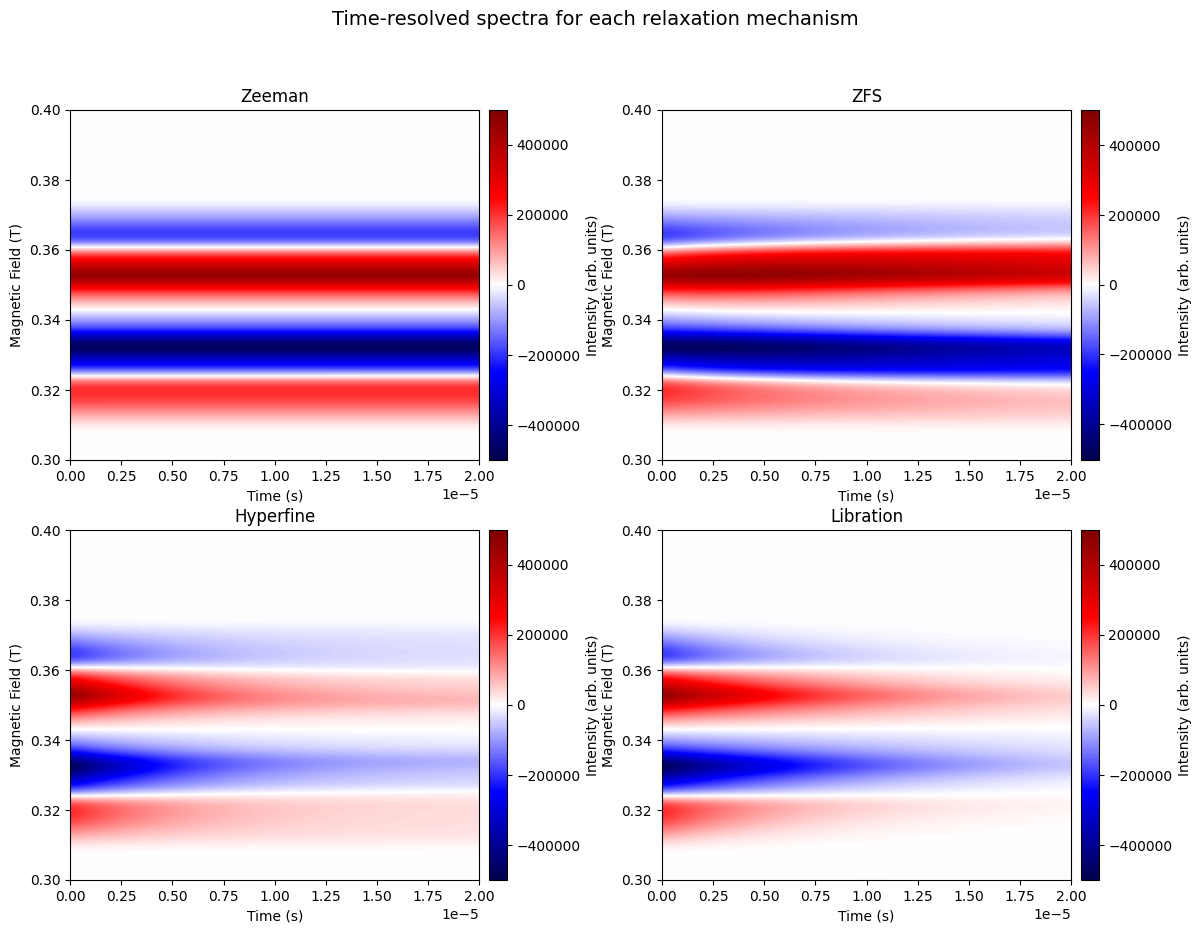

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, spec) in zip(axes, spectra.items()):
    plt.sca(ax)
    visualization.time_resolved.plot_2d_timeresolved(fields, times, spec)
    plt.title(name)
plt.suptitle("Time‑resolved spectra for each relaxation mechanism", fontsize=14)
plt.show()

# 9. Visualisation of Polarized Spectra

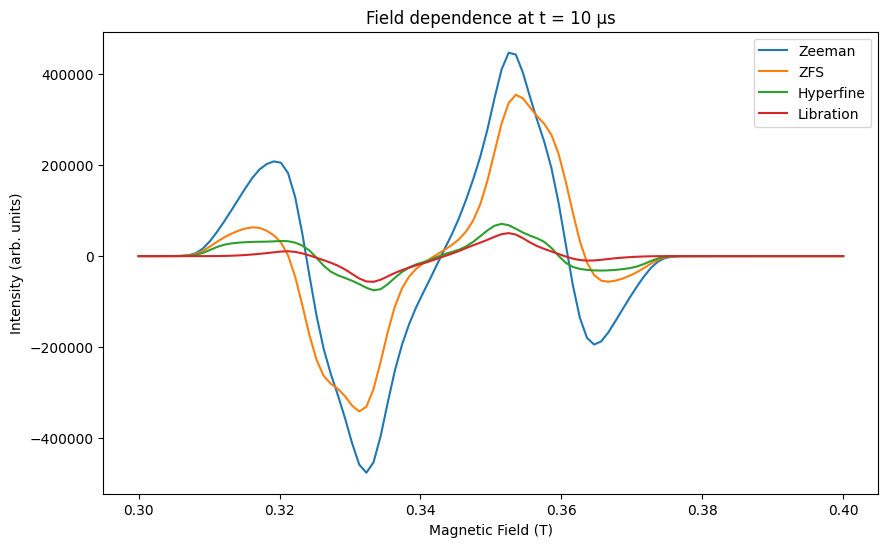

In [15]:
fig2, ax2 = plt.subplots(figsize=(10, 6))
t_target = 2e-5

for name, spec in spectra.items():
    visualization.plot_field_dependence(time_value=t_target, fields=fields,
                              time=times, result=spec, label=name)

ax2.set_title("Field dependence at t = 10 μs")
ax2.legend()
plt.show()

In general, each relaxation mechanism produces a distinct pattern of
population transfer. 

Note, that all coupling operators were
normalised to the *same* dimensionless amplitude in this demonstration.
In a real spin system the intrinsic fluctuations – for instance,
$\Delta g_{\mathrm{iso}}$, $\Delta D$, $\Delta A_{\mathrm{iso}}$, or
the r.m.s. libration angle – can differ by orders of magnitude.
Consequently the absolute relaxation rates scale with the actual physical
amplitudes, and the relative importance of the various channels may shift
substantially.